# Regression and In-Between Uncertainty

This notebook illustrates IVON on a simple regression problem, showing how it can capture uncertainty in regions with little date.

In [1]:
import torch
import matplotlib.pyplot as plt
import math
from ivon import IVON
from evon import EVON

plt.rcParams.update(
    {
        'font.family': 'serif',
        'font.serif': ['Times', 'Times New Roman', 'Liberation Serif', 'DejaVu Serif'],
        'axes.labelsize': 8,
        'font.size': 8,
        'legend.fontsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.edgecolor': 'gray',
        'xtick.color': 'gray',
        'ytick.color': 'gray',
        'xtick.major.size': 2,
        'xtick.major.width': 0.5,
        'ytick.major.size': 2,
        'ytick.major.width': 0.5,
        'xtick.minor.size': 1,
        'xtick.minor.width': 0.5,
        'ytick.minor.size': 1,
        'ytick.minor.width': 0.5,
    }
)

%config InlineBackend.figure_format = "svg"

Create and visualize the dataset.

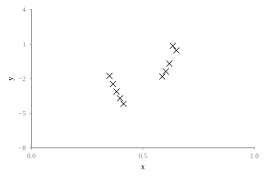

In [2]:
def make_toy_data(n=20):
    std = torch.logspace(-3, 0, n)
    x = torch.linspace(0.35, 0.65, n)
    y = 5 * torch.sin(10 * x) + std * torch.randn_like(x)

    # Keep only the first and last 5 points
    x = torch.cat((x[:5], x[-5:]))
    y = torch.cat((y[:5], y[-5:]))

    return x[:, None], y[:, None]


def plot_data(X, y, yl=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 2.5))
    else:
        fig = None

    ax.plot(X.squeeze(), y.squeeze(), 'x', color='black', markeredgewidth=0.6)

    ax.set(
        xlabel='x',
        ylabel='y',
        xlim=(0, 1),
        ylim=yl,
        xticks=torch.linspace(0, 1, 3),
        yticks=torch.linspace(yl[0], yl[1], 5),
    )

    return fig, ax


torch.manual_seed(42)
X, y = make_toy_data()
fig, ax = plot_data(X, y, yl=(-8, 4))

Train a MLP with IVON.

In [3]:
def make_model():
    hidden = 64
    nonlin = torch.nn.ELU()
    m = torch.nn.Sequential(
        torch.nn.Linear(1, hidden),
        nonlin,
        torch.nn.Linear(hidden, hidden),
        nonlin,
        torch.nn.Linear(hidden, hidden),
        nonlin,
        torch.nn.Linear(hidden, hidden),
        nonlin,
        torch.nn.Linear(hidden, 1),
    )

    return m


model = make_model()

# for ess, try out:
# - 1e6 (almost static weights),
# - 1e5 to 1e4 (good trade-off)
# - 1e3 (very noisy weights)
opt = IVON(
    model.parameters(), 
    lr=0.02, 
    ess=2e4, 
    weight_decay=1e-5, 
    hess_init=0.01, 
    beta1=0.9,
    beta2=0.9995, 
    clip_radius=0.1,
    rescale_lr=False
)

loss_fn = torch.nn.MSELoss()
n_steps = 5000
sched = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt,
    T_max=n_steps,
    eta_min=0.0,
)

for _ in range(n_steps + 1):
    with opt.sampled_params(train=True):
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()

    opt.step()
    sched.step()

Train a MLP with EVON. Where IVON uses a diagonal covariance, EVON runs the same update in the eigenspace of the SOAP preconditioner, so the covariance is non-diagonal and can adapt to correlations between weights.

In [4]:
model_evon = make_model()

opt_evon = EVON(
    model_evon.parameters(), 
    lr=0.02, 
    ess=3e4, 
    weight_decay=1e-5, 
    hess_init=0.004, 
    betas=(0.9, 0.9999),
    mc_samples=1,
    precondition_frequency=10,
    whiten_prec_grad=True,
)

loss_fn = torch.nn.MSELoss()
n_steps = 5000
sched_evon = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_evon,
    T_max=n_steps,
    eta_min=0.0,
)

for _ in range(n_steps + 1):
    with opt_evon.sampled_params(train=True):
        opt_evon.zero_grad()
        loss = loss_fn(model_evon(X), y)
        loss.backward()

    opt_evon.step()
    sched_evon.step()

Visualize the resulting uncertainty.

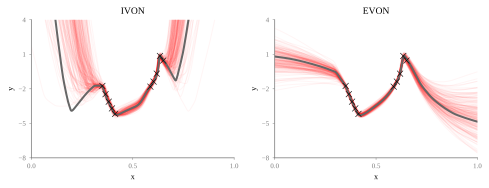

In [5]:
x_eval = torch.linspace(0, 1, 500)[:, None]

with torch.no_grad():
    y_mean = model(x_eval).squeeze()
    y_mean_evon = model_evon(x_eval).squeeze()

ys = []
with torch.no_grad():
    for _ in range(200):
        with opt.sampled_params(train=False):
            ys.append(model(x_eval).squeeze())
ys = torch.stack(ys)

ys_evon = []
with torch.no_grad():
    for _ in range(200):
        with opt_evon.sampled_params(train=False):
            ys_evon.append(model_evon(x_eval).squeeze())
ys_evon = torch.stack(ys_evon)

xe = x_eval.squeeze()
# pinned ylim: IVON's posterior diverges far from the data, a dynamic
# range here would squash the in-between region we want to compare
yl = (-8, 4)

fig, (ax_ivon, ax_evon) = plt.subplots(1, 2, figsize=(8, 2.5))

plot_data(X, y, yl=yl, ax=ax_ivon)
ax_ivon.plot(xe, ys.T, c='red', alpha=0.04, lw=1, zorder=-2)
ax_ivon.plot(xe, y_mean, c='0.4', lw=2, zorder=-1)
ax_ivon.set_title('IVON')

plot_data(X, y, yl=yl, ax=ax_evon)
ax_evon.plot(xe, ys_evon.T, c='red', alpha=0.04, lw=1, zorder=-2)
ax_evon.plot(xe, y_mean_evon, c='0.4', lw=2, zorder=-1)
ax_evon.set_title('EVON');

Next, train an IVON whose Hessian estimate is pinned (`beta2=1.0`). Every coordinate keeps the same variance, so the posterior is an isotropic Gaussian. Compared to notebook 2's configuration, the learning rate is smaller here, which keeps training stable on this regression.

In [6]:
model_ivon_iso = make_model()

opt_ivon_iso = IVON(
    model_ivon_iso.parameters(),
    lr=0.02,
    ess=5e1,
    weight_decay=1e-5,
    hess_init=1.0,
    beta1=0.9,
    beta2=1.0,
    clip_radius=0.5,
    rescale_lr=False
)

sched_iso = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_ivon_iso,
    T_max=n_steps,
    eta_min=0.0,
)

for _ in range(n_steps + 1):
    with opt_ivon_iso.sampled_params(train=True):
        opt_ivon_iso.zero_grad()
        loss = loss_fn(model_ivon_iso(X), y)
        loss.backward()
    opt_ivon_iso.step()
    sched_iso.step()


## Posterior covariance structure

Draw the exact posterior covariance of each network on a strided subset of the parameters, ordered layer by layer. The first IVON keeps `beta2=1.0`, so its Hessian estimate stays pinned at the init and its covariance is a scaled identity; the second IVON learns its Hessian estimate (`beta2=0.9995`), so the diagonal entries differ by orders of magnitude. EVON's covariance is diagonal only in the per-layer SOAP eigenspaces, which translates to a block-diagonal structure in weight space: dense within each layer, zero across layers.

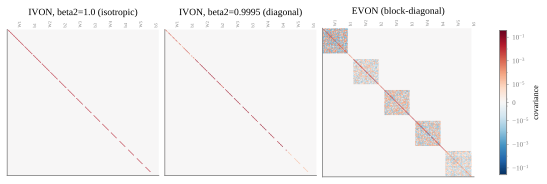

In [7]:
import torch
from matplotlib.colors import SymLogNorm

# Exact posterior covariance on a subset of parameters (72 strided weights and
# 16 strided biases per tensor), assembled block by block in layer order.
# - IVON, beta2=1.0: the Hessian estimate is pinned, so
#   sigma^2 = 1 / (ess * (hess_init + weight_decay)) is the same everywhere.
# - IVON, beta2=0.9995: sigma^2_i = 1 / (ess * (hess_i + weight_decay)) per
#   coordinate, learned from the data.
# - EVON weights: Cov(W_ab, W_cd) = sum_kl Q0[a,k] Q0[c,k] S2[k,l] Q1[b,l] Q1[d,l]
#   with S2 = 1 / (ess * (h_mom + weight_decay)) in the preconditioner eigenspace.
# - EVON biases: 1-D tensors are not preconditioned, so they stay diagonal.
def posterior_cov_blocks(module, opt, kind, n_w=72, n_b=16):
    blocks = []
    offset = 0
    for name, p in module.named_parameters():
        numel = p.numel()
        if kind == "ivon":
            g = opt.param_groups[0]
            std = (g["ess"] * (g["hess"] + g["weight_decay"])).rsqrt()
            idx = torch.linspace(0, numel - 1, steps=(n_w if p.ndim == 2 else n_b)).long()
            blocks.append(torch.diag(std[offset + idx] ** 2))
        else:
            state = opt.state[p]
            g = opt.param_groups[0]
            s2 = 1.0 / (g["ess"] * (state["h_mom"] + g["weight_decay"]))
            if p.ndim == 1:
                idx = torch.linspace(0, numel - 1, steps=min(n_b, numel)).long()
                blocks.append(torch.diag(s2[idx]))
            else:
                Q0, Q1 = state["Q"][0].float(), state["Q"][1].float()
                out_f, in_f = p.shape
                rows = torch.linspace(0, out_f - 1, steps=min(n_w, out_f)).long()
                cols = torch.linspace(0, in_f - 1, steps=min(n_w, in_f)).long()
                aa, bb = torch.meshgrid(rows, cols, indexing="ij")
                keep = torch.linspace(0, aa.numel() - 1, steps=n_w).long()
                aa, bb = aa.reshape(-1)[keep], bb.reshape(-1)[keep]
                T = Q0[aa].unsqueeze(2) * Q1[bb].unsqueeze(1)
                blocks.append(torch.einsum("kl,akl,bkl->ab", s2, T, T))
        offset += numel
    return blocks


blocks_iso = posterior_cov_blocks(model_ivon_iso, opt_ivon_iso, "ivon")
blocks_diag = posterior_cov_blocks(model, opt, "ivon")
blocks_evon = posterior_cov_blocks(model_evon, opt_evon, "evon")
cov_iso = torch.block_diag(*blocks_iso)
cov_diag = torch.block_diag(*blocks_diag)
cov_evon = torch.block_diag(*blocks_evon)

panels = [
    (cov_iso, "IVON, beta2=1.0 (isotropic)"),
    (cov_diag, "IVON, beta2=0.9995 (diagonal)"),
    (cov_evon, "EVON (block-diagonal)"),
]

ticks, tickvals = [], []
n = 0
for j, Cb in enumerate(blocks_iso):
    n += Cb.shape[0]
    ticks.append(n - Cb.shape[0] / 2)
    tickvals.append(f"{'W' if j % 2 == 0 else 'b'}{j // 2 + 1}")
# One shared color scale across all three panels.
vmax = max(C.abs().max().item() for C, _ in panels)
norm = SymLogNorm(linthresh=vmax * 1e-5, vmin=-vmax, vmax=vmax)

fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.7), sharey=True, layout="constrained")
for ax, (C, title) in zip(axes, panels):
    im = ax.imshow(C.numpy(), cmap="RdBu_r", norm=norm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks(ticks, tickvals, fontsize=4.5, rotation=90)
    ax.tick_params(length=0, pad=2)
    ax.xaxis.set_ticks_position("top")
    ax.set_yticks([])

decade = 10 ** torch.floor(torch.log10(torch.tensor(vmax))).item()
cb = fig.colorbar(
    im,
    ax=axes,
    shrink=0.8,
    ticks=[decade, decade * 1e-2, decade * 1e-4, 0, -decade * 1e-4, -decade * 1e-2, -decade],
)
cb.set_label("covariance")


## Per-layer covariance structure

The same three posteriors, one row per weight matrix, on strided entry subsets of each layer; the three panels of a row share one color scale. Biases are omitted: as 1-D tensors they are diagonal for all three posteriors.

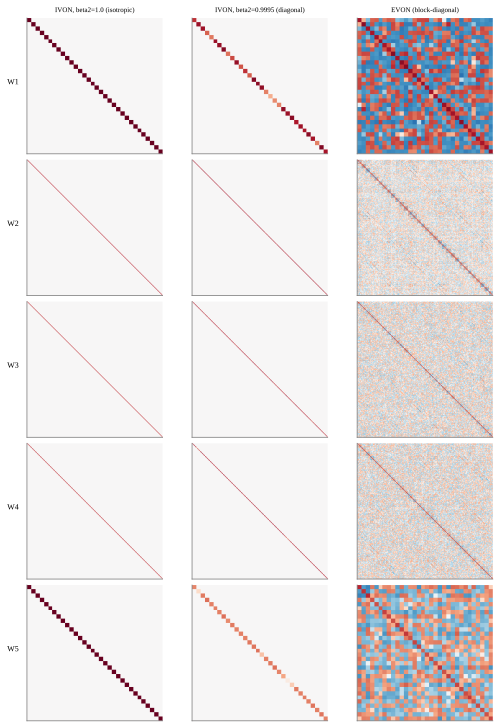

In [8]:
def layer_cov_ivon(p, opt, offset, n_side=32):
    g = opt.param_groups[0]
    var = 1.0 / (g["ess"] * (g["hess"] + g["weight_decay"]))
    out_f, in_f = p.shape
    rows = torch.linspace(0, out_f - 1, steps=min(n_side, out_f)).long()
    cols = torch.linspace(0, in_f - 1, steps=min(n_side, in_f)).long()
    aa, bb = torch.meshgrid(rows, cols, indexing="ij")
    flat = aa.reshape(-1) * in_f + bb.reshape(-1) + offset
    return torch.diag(var[flat])


def layer_cov_evon(p, opt, n_side=32):
    state = opt.state[p]
    g = opt.param_groups[0]
    s2 = 1.0 / (g["ess"] * (state["h_mom"] + g["weight_decay"]))
    Q0, Q1 = state["Q"][0].float(), state["Q"][1].float()
    out_f, in_f = p.shape
    rows = torch.linspace(0, out_f - 1, steps=min(n_side, out_f)).long()
    cols = torch.linspace(0, in_f - 1, steps=min(n_side, in_f)).long()
    aa, bb = torch.meshgrid(rows, cols, indexing="ij")
    aa, bb = aa.reshape(-1), bb.reshape(-1)
    T = Q0[aa].unsqueeze(2) * Q1[bb].unsqueeze(1)
    return torch.einsum("kl,akl,bkl->ab", s2, T, T)


# The two IVONs and EVON own separate parameter objects, so keep one weight
# list per network; the architectures match, so row r corresponds across lists.
layers, offset = [], 0
for name, p in model.named_parameters():
    if p.ndim == 2:
        layers.append((name, p, offset))
    offset += p.numel()
layers_evon = [p for p in model_evon.parameters() if p.ndim == 2]

titles = [
    "IVON, beta2=1.0 (isotropic)",
    "IVON, beta2=0.9995 (diagonal)",
    "EVON (block-diagonal)",
]

fig, axes = plt.subplots(
    len(layers), 3,
    figsize=(7.0, 2.0 * len(layers)),
    layout="constrained",
)
for r, (name, p, off) in enumerate(layers):
    covs = [
        layer_cov_ivon(p, opt_ivon_iso, off),
        layer_cov_ivon(p, opt, off),
        layer_cov_evon(layers_evon[r], opt_evon),
    ]
    vmax = max(C.abs().max().item() for C in covs)
    norm = SymLogNorm(linthresh=vmax * 1e-5, vmin=-vmax, vmax=vmax)
    norms = [norm] * 3
    for c, (C, norm) in enumerate(zip(covs, norms)):
        ax = axes[r, c]
        ax.imshow(C.numpy(), cmap="RdBu_r", norm=norm, interpolation="nearest")
        ax.set_xticks([])
        ax.set_yticks([])
    axes[r, 0].set_ylabel(f"W{r + 1}", rotation=0, labelpad=14)
for c, t in enumerate(titles):
    axes[0, c].set_title(t, fontsize=7)
